# e-SNLI Batch Denoising — Corpus-level Continuous TF-IDF

In [1]:
import sys, os

sys.path.insert(0, os.path.dirname(os.getcwd()))

import random

import torch
from src.configs import SAEConfig
from src.denoiser import Denoiser
from src.configs import DenoisingConfig
from src.utils.activations_utils import top_k_features_per_token
from src.utils.visualization import plot_per_token_topk_heatmap, plot_token_activation_ridgeplot

## Load activations from disk

In [2]:
DATA_PATH = "../data/activations/esnli-l40-65k.pt"

data = torch.load(DATA_PATH, weights_only=False)

sae_encodings = data["sae_encodings"]
recon_stats = data["recon_stats"]
sequences = data["sequence"]
prompt_char_lens = data["prompt_lens"]
generation_token_ids = data.get("generation_token_ids")
dataset_info = data["dataset_info"]
sae_cfg_dict = data["sae_config"]

sae_config = SAEConfig(**sae_cfg_dict)

n_prompts = len(sae_encodings)
total_tokens = sum(enc.shape[0] for enc in sae_encodings)
n_features = sae_encodings[0].shape[1]
mean_fvu = sum(s["fvu"] for s in recon_stats) / len(recon_stats)
mean_l0 = sum(s["l0"] for s in recon_stats) / len(recon_stats)

print(f"Prompts:         {n_prompts}")
print(f"Total tokens:    {total_tokens}")
print(f"Features (d_sae): {n_features}")
print(f"Mean FVU:        {mean_fvu:.4f}")
print(f"Mean L0:         {mean_l0:.1f}")
print(f"SAE config:      {sae_config}")

Prompts:         500
Total tokens:    72852
Features (d_sae): 65536
Mean FVU:        0.0229
Mean L0:         57.6
SAE config:      SAEConfig(repo_id='google/gemma-scope-2-27b-it', sae_type='resid_post', layer=40, width='65k', l0='medium')


In [3]:
print([k for k in data.keys()])

['sae_encodings', 'recon_stats', 'sequence', 'prompt_lens', 'generation_token_ids', 'dataset_info', 'sae_config']


In [4]:
print(data["sae_encodings"][0])


tensor(indices=tensor([[    0,     0,     0,  ...,   148,   148,   148],
                       [  142,   240,   411,  ..., 38911, 52942, 62451]]),
       values=tensor([574.1371, 442.1205, 491.8810,  ..., 612.6995,
                      512.8052, 574.3268]),
       size=(149, 65536), nnz=9691, layout=torch.sparse_coo)


## Compute corpus-level IDF, sample one prompt, and denoise

In [5]:
THRESHOLD = 10.0

idf, corpus_total = Denoiser.compute_corpus_idf(sae_encodings, threshold=THRESHOLD)
print(f"Corpus total tokens: {corpus_total}")
print(f"IDF vector shape:    {idf.shape}")
print(f"IDF range:           [{idf.min():.3f}, {idf.max():.3f}]")

seed = random.randint(0, 2**32 - 1)
random.seed(seed)
sample_idx = random.randint(0, n_prompts - 1)
print(f"\nRandom seed: {seed}")
print(f"Sampled prompt index: {sample_idx}")

sample_sparse = sae_encodings[sample_idx]
sample_acts = sample_sparse.to_dense().float()
denoised_acts = Denoiser.apply_tfidf(sample_acts, idf)

denoising_config = DenoisingConfig(method="continuous_tfidf", params={"threshold": 10.0})
denoiser = Denoiser()
locally_denoised_acts = denoiser.denoise(sample_acts, denoising_config)

gen_text = sequences[sample_idx][prompt_char_lens[sample_idx]:]
ground_truth = dataset_info["ground_truths"][sample_idx]

print(f"\nGround truth label: {ground_truth}")
print(f"Generation tokens:  {sample_acts.shape[0]}")
print(f"Generation text:    {gen_text[:200]}...")

Computing corpus IDF: 100%|██████████| 500/500 [00:51<00:00,  9.62it/s]


Corpus total tokens: 72852
IDF vector shape:    torch.Size([65536])
IDF range:           [0.955, 11.196]

Random seed: 1775304650
Sampled prompt index: 435

Ground truth label: entailment
Generation tokens:  128
Generation text:    
<reasoning>
The premise states that men and women are walking down a sidewalk *next to* a garden. If they are walking down a sidewalk next to something, it logically follows that they are walking *by...


## HuggingFace Authentication

In [6]:
import sys
from huggingface_hub import login

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    import google.colab.userdata
    hf_token = google.colab.userdata.get("HFWrite")
    login(token=hf_token)
else:
    from dotenv import load_dotenv
    load_dotenv()
    hf_token = os.getenv("HF_TOKEN")
    login(token=hf_token)
        

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Tokenize the sampled generation for heatmap labels

In [7]:
MODEL_NAME = "google/gemma-3-27b-it"

try:
    from transformers import AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=True)

    if generation_token_ids is not None:
        gen_ids = generation_token_ids[sample_idx]
        tokens = tokenizer.convert_ids_to_tokens(gen_ids)
    else:
        token_ids = tokenizer.encode(gen_text, add_special_tokens=False)
        tokens = tokenizer.convert_ids_to_tokens(token_ids)

    if len(tokens) != denoised_acts.shape[0]:
        print(
            f"Token count mismatch: tokenizer produced {len(tokens)}, "
            f"activations have {denoised_acts.shape[0]}. "
            f"Falling back to positional labels."
        )
        tokens = [f"t_{i}" for i in range(denoised_acts.shape[0])]
except Exception as e:
    print(f"Could not load tokenizer ({e}); using positional labels.")
    tokens = [f"t_{i}" for i in range(denoised_acts.shape[0])]

print(f"Token count: {len(tokens)}")
print(f"First 10 tokens: {tokens[:10]}")

Token count: 128
First 10 tokens: ['\n', '<', 'reason', 'ing', '>', '\n', 'The', '▁premise', '▁states', '▁that']


## Ridgeplot: Token Activation Distributions

/workspace/LASR/activations-script/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/workspace/LASR/activations-script/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/workspace/LASR/activations-script/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


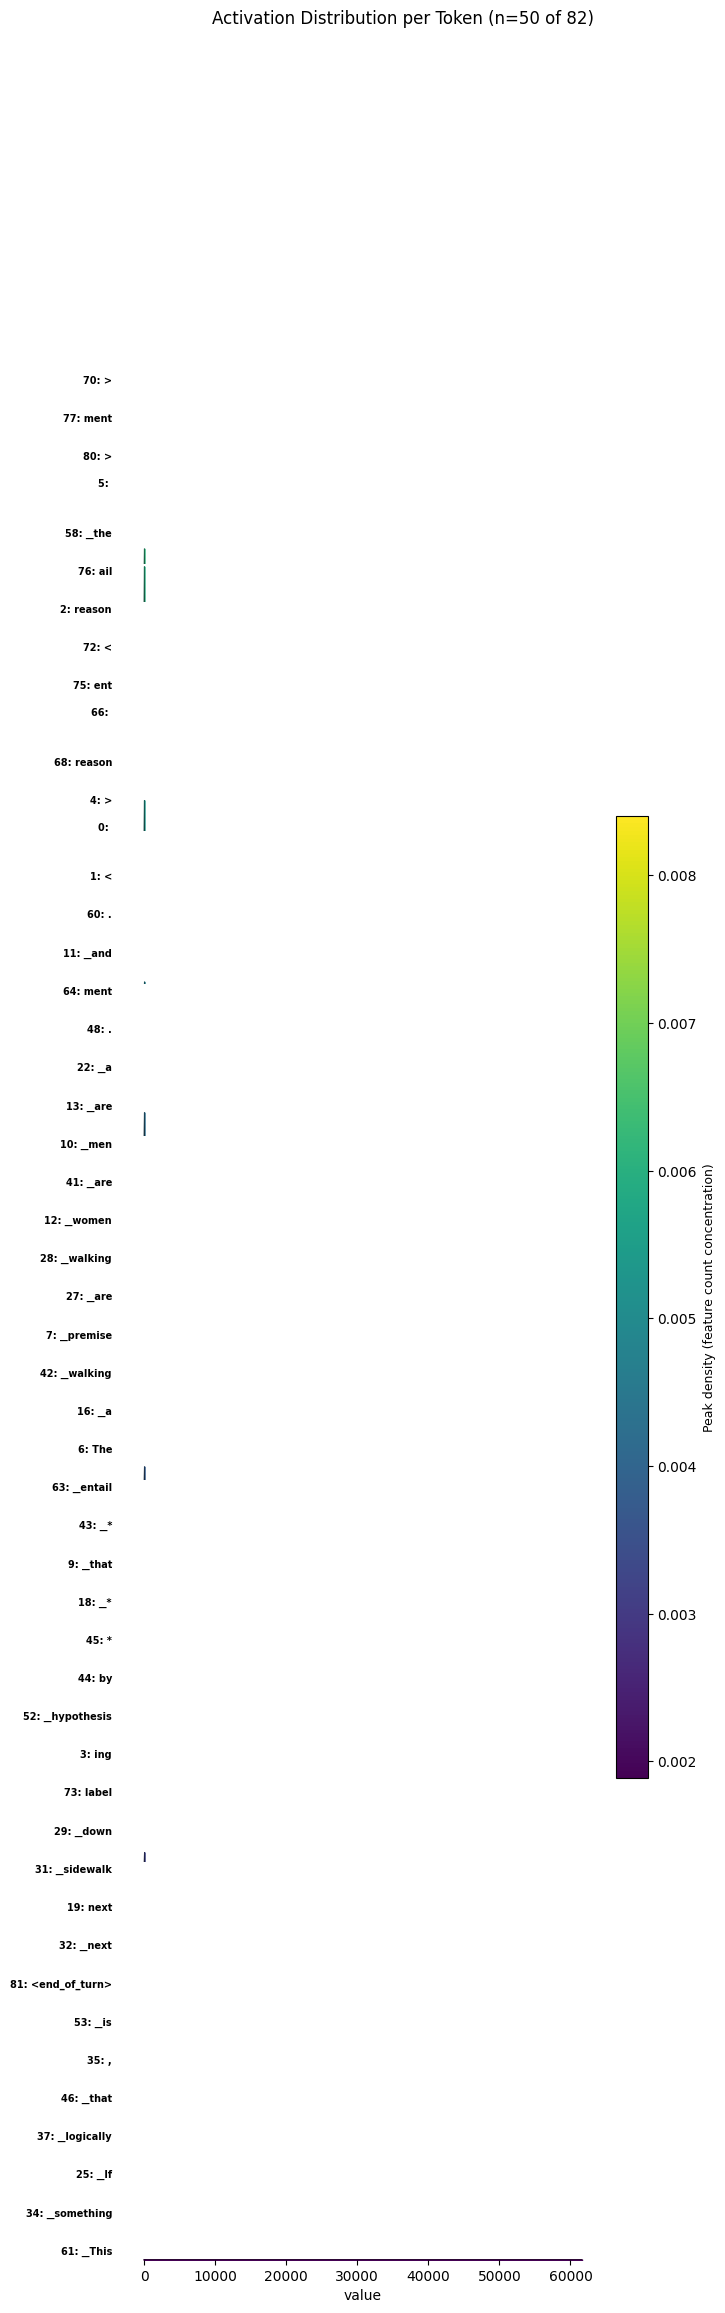

In [8]:
N_TOKENS_RIDGE = 50  # 0 = show all tokens (capped at max_tokens)

PAD_TOKEN = "<pad>"
non_pad_mask = [t != PAD_TOKEN for t in tokens]
ridge_acts = denoised_acts[non_pad_mask]
ridge_tokens = [t for t in tokens if t != PAD_TOKEN]

fig = plot_token_activation_ridgeplot(
    ridge_acts,
    ridge_tokens,
    n_tokens=N_TOKENS_RIDGE,
    seed=seed,
)
fig.show()

## Top-K denoised feature heatmap

In [9]:
from src.utils.visualization import summarize_latents

TOP_K = 15

global_denoised_features = summarize_latents(
    denoised_acts,
    tokens=tokens,
    model_name=MODEL_NAME,
    sae_config=sae_config,
    top_k=TOP_K,
    print_first_n=0,
    full_sae_activations=sample_acts,
    all_tokens=tokens,
)


Created 857 Feature objects
Example: Feature(idx=8, description='evaluating complexity and worth', max_act=1801.75, n_tokens=128)


## Top-K original feature heatmap

In [10]:
original_features = summarize_latents(
    sample_acts,
    tokens=tokens,
    model_name=MODEL_NAME,
    sae_config=sae_config,
    top_k=TOP_K,
    print_first_n=0,
    full_sae_activations=sample_acts,
    all_tokens=tokens,
)


Created 579 Feature objects
Example: Feature(idx=8, description='evaluating complexity and worth', max_act=1801.75, n_tokens=128)


## Top-K locally-denoised feature heatmap

In [11]:
local_denoised_features = summarize_latents(
    locally_denoised_acts,
    tokens=tokens,
    model_name=MODEL_NAME,
    sae_config=sae_config,
    top_k=TOP_K,
    print_first_n=0,
    full_sae_activations=sample_acts,
    all_tokens=tokens,
)


Created 840 Feature objects
Example: Feature(idx=8, description='evaluating complexity and worth', max_act=1801.75, n_tokens=128)


## Top-K Token/Feature Denoising Breakdown

In [12]:
import math

DISPLAY_TOP_K = TOP_K

top1_vals, top1_idxs = top_k_features_per_token(sample_acts, k=1)
top1_vals = top1_vals.squeeze(-1)
top1_idxs = top1_idxs.squeeze(-1)

sorted_order = torch.argsort(top1_vals, descending=True)
n_display = min(DISPLAY_TOP_K, len(sorted_order))

num_local_docs = sample_acts.shape[0]
local_df_all = (sample_acts > THRESHOLD).sum(dim=0).float()

print(f"{'Rank':<5} {'Token':<20} {'Feature':<8} "
      f"{'Orig Act':>10} │ "
      f"{'Glb DF':>8} {'Glb IDF':>9} {'Glb Denoised':>13} │ "
      f"{'Lcl DF':>8} {'Lcl IDF':>9} {'Lcl Denoised':>13}")
print("─" * 130)

for rank in range(n_display):
    tok_idx = int(sorted_order[rank])
    feat_idx = int(top1_idxs[tok_idx])
    tok_str = tokens[tok_idx]

    orig_act = float(sample_acts[tok_idx, feat_idx])
    global_idf_val = float(idf[feat_idx])
    global_df_val = corpus_total / math.exp(global_idf_val) - 1
    global_denoised_val = float(denoised_acts[tok_idx, feat_idx])

    local_df_val = float(local_df_all[feat_idx])
    local_idf_val = math.log(num_local_docs / (1 + local_df_val))
    local_denoised_val = float(locally_denoised_acts[tok_idx, feat_idx])

    print(f"{rank+1:<5} {tok_str:<20} {feat_idx:<8} "
          f"{orig_act:>10.2f} │ "
          f"{global_df_val:>8.1f} {global_idf_val:>9.4f} {global_denoised_val:>13.2f} │ "
          f"{local_df_val:>8.0f} {local_idf_val:>9.4f} {local_denoised_val:>13.2f}")

Rank  Token                Feature    Orig Act │   Glb DF   Glb IDF  Glb Denoised │   Lcl DF   Lcl IDF  Lcl Denoised
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1     ▁This                1888       11767.83 │    388.0    5.2326      61576.44 │        2    3.7534      44169.60
2     ▁If                  157         8201.47 │    512.0    4.9559      40645.75 │        2    3.7534      30783.55
3     ,                    1574        7565.42 │    811.0    4.4967      34019.30 │        2    3.7534      28396.17
4     ▁something           735         6659.19 │    323.0    5.4154      36062.44 │        2    3.7534      24994.71
5     ▁a                   985         6488.19 │    559.0    4.8682      31586.14 │        1    4.1589      26983.64
6     <end_of_turn>        934         6272.05 │   1170.0    4.1306      25907.14 │        2    3.7534      23541.61
7     <pad>                1235        6073.30 │  

# Visualize Select Features

In [13]:
FEATURES_TO_INSPECT = [0, 0, 0]  # <-- fill in after reviewing heatmap

for feat_idx in FEATURES_TO_INSPECT:
    feat = global_denoised_features[feat_idx]
    print(f"Inspecting feature {feat_idx}")
    print(f"repr: {feat!r}")
    print(f"frac_nonzero: {feat.frac_nonzero}")
    print(f"top_tokens: {feat.top_tokens()}")
    print()
    feat.inspect()

KeyError: 0

## Steering Experiment

### Load Model + SAE

In [ ]:
from src.configs import ModelConfig
from src.gemma_model import GemmaModel
from src.SAE import JumpReLUSAE

model_config = ModelConfig(model_name=MODEL_NAME)
model = GemmaModel(model_config)
sae = JumpReLUSAE.from_pretrained(sae_config, device=model_config.device)

Fetching 12 files:   0%|          | 0/12 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

Load SAE resid_post/layer_40_width_65k_l0_medium/params.safetensors from google/gemma-scope-2-27b-it


resid_post/layer_40_width_65k_l0_medium/(…):   0%|          | 0.00/2.82G [00:00<?, ?B/s]

### Configure Steering

In [ ]:
STEER_FEATURE = 0    # <-- fill in from heatmap / feature_map inspection
STEER_COEFF = 10.0   # <-- fill in (positive = amplify, negative = suppress)

prompt_text = sequences[sample_idx][:prompt_char_lens[sample_idx]]
inputs = tokenizer(prompt_text, return_tensors="pt", add_special_tokens=True)["input_ids"].to(model_config.device)

print(f"Sample index:   {sample_idx}")
print(f"Steer feature:  {STEER_FEATURE}")
print(f"Steer coeff:    {STEER_COEFF}")
print(f"Prompt tokens:  {inputs.shape[1]}")
print(f"Prompt text:    {prompt_text[:200]}...")

Sample index:   288
Steer feature:  0
Steer coeff:    10.0
Prompt tokens:  96
Prompt text:    user Task: Determine the logical relationship between a Premise and a Hypothesis.
Options: entailment, contradiction, neutral.

Rules:
1. You MUST provide your reasoning inside <reasoning> tags.
2. Yo...


### Baseline vs Steered Generation

In [ ]:
result = model.generate_steered(
    prompt=prompt_text,
    sae=sae,
    feature_idx=STEER_FEATURE,
    coeff=STEER_COEFF,
    target_layer=sae_config.layer,
    max_new_tokens=256,
)

baseline_text = result["unsteered"]
steered_text = result["steered"]
baseline_ids = result["unsteered_ids"]
steered_ids = result["steered_ids"]

print(f"{'BASELINE':=^80}")
print(baseline_text)
print()
print(f"{'STEERED (feature={STEER_FEATURE}, coeff={STEER_COEFF})':=^80}")
print(steered_text)
print()
print(f"{'COMPARISON':=^80}")
print(f"Baseline length:  {len(baseline_ids)} tokens")
print(f"Steered length:   {len(steered_ids)} tokens")
print(f"Texts identical:  {baseline_text == steered_text}")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


====================================BASELINE====================================
<bos>user Task: Determine the logical relationship between a Premise and a Hypothesis.
Options: entailment, contradiction, neutral.

Rules:
1. You MUST provide your reasoning inside <reasoning> tags.
2. You MUST provide the final label inside <label> tags.
3. The reasoning must come BEFORE the label.

Premise: Three women in dress suits walk by a building.
Hypothesis: The suits are gray.

model 
<reasoning>The premise states that three women are wearing dress suits, but it does not provide any information about the color of the suits. The suits could be any color. Therefore, the hypothesis does not necessarily follow from the premise, nor does it contradict it. The relationship is neutral. </reasoning>
<label>neutral</label><end_of_turn>

=============STEERED (feature={STEER_FEATURE}, coeff={STEER_COEFF})=============
<bos>user Task: Determine the logical relationship between a Premise and a Hypothesis.
Op